In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14
})

### Non-linear efficiency

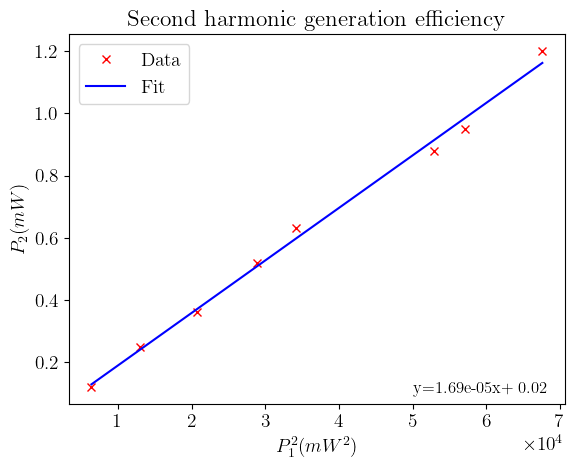

Non-linear efficiency= 1.6881452938299681 %/W


In [35]:
P1_list = np.array([80, 114, 144, 170, 185, 230, 239, 260])
P2_list = np.array([0.12, 0.248, 0.360, 0.520, 0.63, 0.88, 0.95, 1.20])
E_NL, b = np.polyfit(P1_list**2,P2_list, 1)

fig, ax = plt.subplots()
ax.plot(P1_list**2, P2_list, 'rx', label='Data')
ax.plot(P1_list**2, E_NL*P1_list**2 + b, 'b-', label='Fit')
# Forcer la notation scientifique
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.set_xlabel("$P_1^2 (mW^2)$")
ax.set_ylabel("$P_2 (mW)$")
ax.set_title("Second harmonic generation efficiency")
ax.text(50000, 0.1, f"y={E_NL:.2e}x+ {b:.2f}", fontsize=12)
ax.legend()
plt.show()

print("Non-linear efficiency=", E_NL*100*1000,"%/W")


### Phase-matching temperature

(0.0, 50.0)

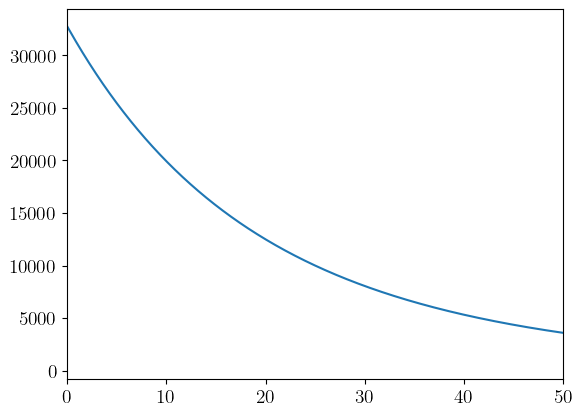

In [82]:
R_list = np.linspace(800,32770,1000)  # Resistance values in ohms


# We need to convert the resistance R into temperature T 
# https://www.thorlabs.com/item/TH10K
R = 10e3  # Resistance in ohms at 25 degrees Celsius
T_list = []

def T(r) : 
    if r < 3560:
        a, b, c, d = 0.003353045, 0.0002542, 1.14261e-6, -6.93803e-8
    if r >= 3560:
        a, b, c, d = 0.003354016, 0.000256173, 2.13941e-6, -7.25325e-8
    return 1 / (a + b * np.log(r / R) + c * (np.log(r / R))**2 + d * (np.log(r / R))**3) - 273.15


plt.plot([T(r) for r in R_list], R_list)
plt.xlim(0,50)

In [ ]:
R_list = np.array([])
P2_list = np.array([])
T_list = [T(r=r) for r in R_list]
plt.plot(T_list, P2_list)
print("Phase-matching temperature is:", T_list[np.argmax(P2_list)])

### SHG efficiency

In [44]:
#Input field
E1 = np.sqrt(0.6)

#Non linear efficiency 
Enl = 0.02


#Reflexion and transmission coeff
r1 = np.sqrt(1 - 0.12)
t1 = np.sqrt(1 - r1**2)
r2 = 1
t2 = np.sqrt(1 - r2**2)
r3 = 1
t3 = np.sqrt(1 - r3**2)
r4 = 1
t4 = np.sqrt(1 - r4**2)

#Linear losses
Lc = 0.02

#Losses due to non linear conversion
gamma = Enl

#Cavity field
#Ec = E1 * t1 / (1-r1*r2*r3*r4*np.sqrt(1 - gamma*Ec**2))

#New variables
lambd = t1**2 + Lc
rho = 4*t1**2*E1**2*Enl

#Ouput field
u = 1 + 13.5*rho/lambd**3*(1 + np.sqrt(1 + 4/27*lambd**3/rho))
P2 = lambd**2 / (9*Enl) * (u**(1/6) - u**(-1/6))**4

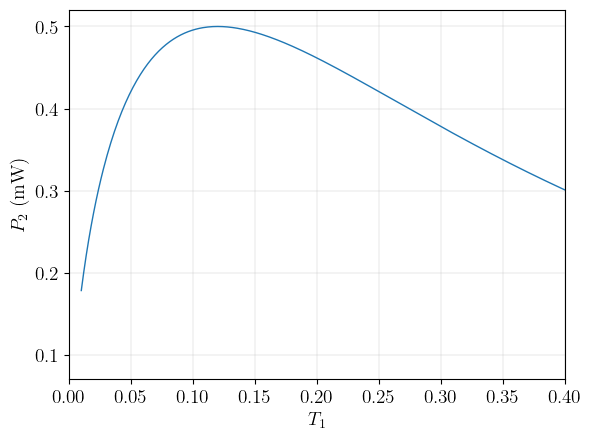

In [60]:
#Plot output field vs transmission for a fixed input field

def output_field(T1, E1) : 
    lambd = T1 + Lc
    rho = 4*T1*E1**2*Enl
    u = 1+13.5*rho/lambd**3*(1 + np.sqrt(1 + 4/27*lambd**3/rho))
    v = 1+13.5*rho/lambd**3*(1 - np.sqrt(1 + 4/27*lambd**3/rho))
    P2 = lambd**2 / (9*Enl) * (u**(1/6) - u**(-1/6))**4
    return P2

transmission = np.linspace(0.01,1,1000)
out_field = [output_field(t, E1=np.sqrt(0.6)) for t in transmission]

fig, ax = plt.subplots()

ax.plot(transmission, out_field, linewidth = 1)
ax.set_xlabel('$T_1$')
ax.set_ylabel('$P_2$ (mW)')
ax.set_xlim(0, 0.4)
ax.grid(linewidth = 0.2)
plt.show()

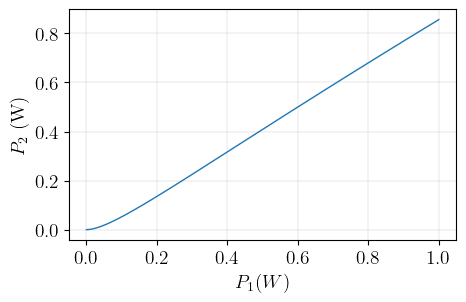

In [75]:
#Plot output field vs input field for a fixed transmission

input_field = np.linspace(0.01,1,1000)
out_field = [output_field(T1=0.12, E1=inp) for inp in input_field]

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(input_field**2, out_field, linewidth = 1)
ax.set_xlabel('$P_1 (W)$')
ax.set_ylabel('$P_2$ (W)')
ax.grid(linewidth = 0.2)
plt.show()

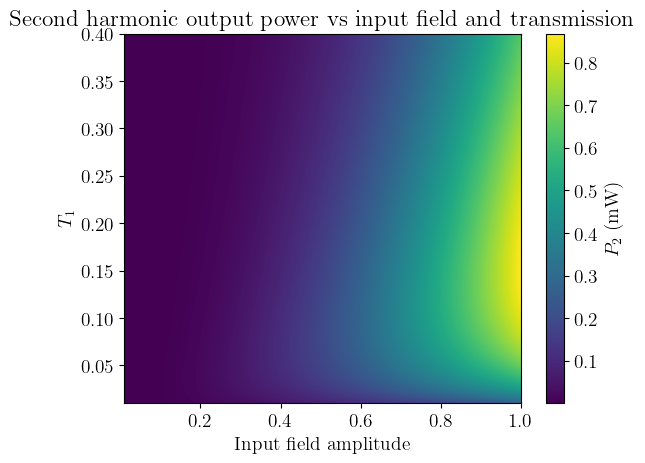

In [62]:
#Plot output field vs input field and transmission

transmission = np.linspace(0.01,0.4,1000)
input_field = np.linspace(0.01,1,1000)
out_field = np.zeros((len(transmission), len(input_field)))
for i, T1 in enumerate(transmission):
    for j, E1 in enumerate(input_field):
        out_field[i, j] = output_field(T1, E1)

plt.imshow(out_field, extent=(0.01,1,0.01,0.4), origin='lower', aspect='auto')
plt.colorbar(label='$P_2$ (mW)')
plt.ylabel('$T_1$')
plt.xlabel('Input field amplitude')
plt.title('Second harmonic output power vs input field and transmission')
plt.show()

Text(0.5, 1.0, 'Transmission at which SHG output is maximum vs input power')

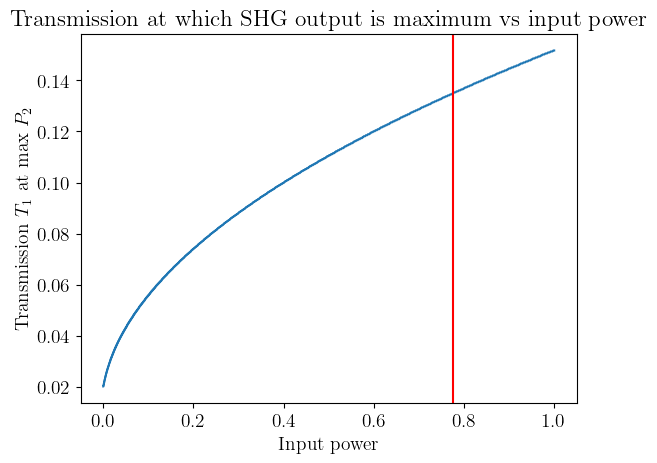

In [73]:
#Plot transmission at which SHG output is maximum vs input field amplitude

transmission = np.linspace(0.01,0.4,1000)
input_field = np.linspace(0.01,1,1000)
out_field = np.zeros((len(transmission), len(input_field)))
for i, T1 in enumerate(transmission):
    for j, E1 in enumerate(input_field):
        out_field[i, j] = output_field(T1, E1)

list_max_T1 = []
for j, E1 in enumerate(input_field):
    column = out_field[:, j]
    max_index = np.argmax(column)
    list_max_T1.append(transmission[max_index])

fig, ax = plt.subplots()
ax.plot(input_field**2, list_max_T1)
ax.set_xlabel('Input power')
ax.set_ylabel('Transmission $T_1$ at max $P_2$')
ax.axvline(np.sqrt(0.6), color='r')
ax.set_title('Transmission at which SHG output is maximum vs input power')

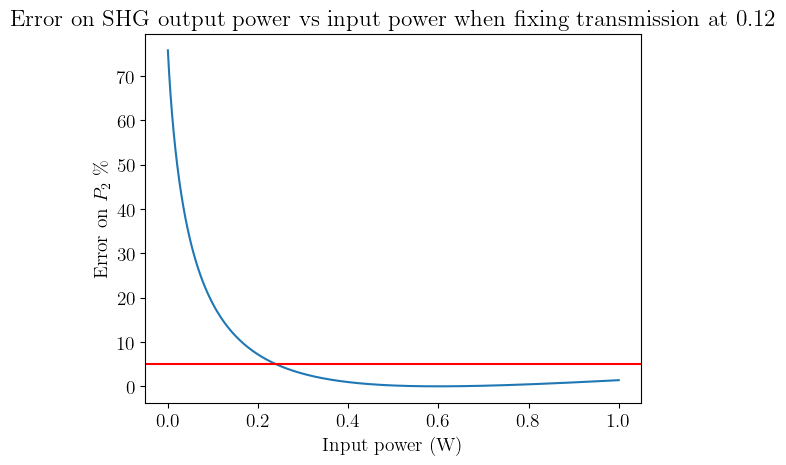

In [71]:
#Error on SHG output power when fixing transmission at 0.12 vs input field

error_P2 = []

for j, E1 in enumerate(input_field):
    max_P2 = out_field[:, j].max()
    P2_fixed_T1 = output_field(0.12, E1)
    error = abs(max_P2 - P2_fixed_T1) / max_P2 * 100
    error_P2.append(error)  

fig, ax = plt.subplots()
ax.plot(input_field**2, error_P2)
ax.set_xlabel('Input power (W)')
ax.set_ylabel(r'Error on $P_2$ \%')
ax.axhline(5, color='r')
ax.set_title('Error on SHG output power vs input power when fixing transmission at 0.12')
plt.show()  